# bike sharing demand (regression)

In [1]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import random
import numpy as np

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
#    torch.manual_seed(seed)
#    torch.cuda.manual_seed(seed)
#    torch.backends.cudnn.deterministic = True
#    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [3]:
import xgboost as xgb ## XGBoost 불러오기
from xgboost import plot_importance ## Feature Importance를 불러오기 위함
from sklearn import datasets
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
!rm -f *.zip *.csv *.txt

In [ ]:
!kaggle competitions download -c bike-sharing-demand

In [ ]:
!unzip -q bike-sharing-demand.zip

In [4]:
df = pd.read_csv("train.csv")

In [5]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [6]:
df.tail()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129
10885,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88


In [7]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [9]:
df.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [10]:
df['datetime'] = pd.to_datetime(df['datetime'])

df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['minute'] = df['datetime'].dt.minute
df['second'] = df['datetime'].dt.second

In [11]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,minute,second
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,0,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,0,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,0,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,0,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,0,0


In [12]:
df.drop(['datetime', 'year', 'minute', 'second'], axis=1, inplace=True)

In [13]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,1
2,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,1,2
3,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,1,3
4,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,1,4


In [14]:
y_data = df[['count']].values
df.drop(['casual', 'registered', 'count'], axis=1, inplace=True)
X_data = df.values

In [15]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0,1,1,1
2,1,0,0,1,9.02,13.635,80,0.0,1,1,2
3,1,0,0,1,9.84,14.395,75,0.0,1,1,3
4,1,0,0,1,9.84,14.395,75,0.0,1,1,4


In [16]:
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2) # train과 validation을 8:2로 분할

In [17]:
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.08, gamma=0, subsample=0.75,
                           colsample_bytree=1, max_depth=7)

In [18]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [19]:
y = model.predict(X_train)

In [20]:
print(model.score(X_train, y_train))

0.9303442239761353


In [21]:
print(model.score(X_val, y_val))

0.8793966770172119


In [22]:
from sklearn import metrics

y_pred = model.predict(X_val)
print('mean_absolute_error: ', metrics.mean_absolute_error(y_val, y_pred)) # best는 0.0
print('mean_squared_error: ', metrics.mean_squared_error(y_val, y_pred)) # best는 0.0
print(f'MAPE: ', metrics.mean_absolute_percentage_error(y_val, y_pred) * 100) # best는 0.0%
print('r2_score: ', metrics.r2_score(y_val, y_pred)) # best는 1.0

mean_absolute_error:  42.64687728881836
mean_squared_error:  3980.74658203125
MAPE:  45.88598310947418
r2_score:  0.8793966770172119


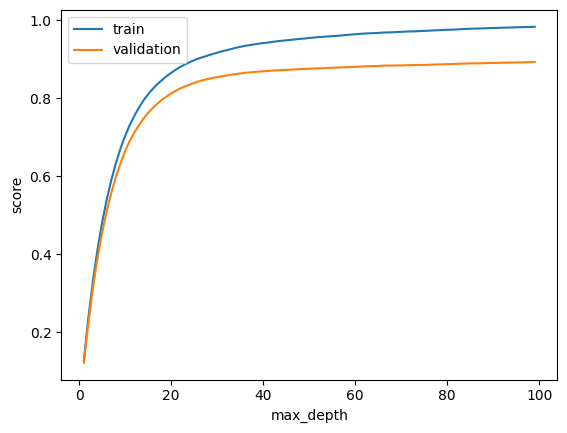

In [23]:
train_score = []
val_score = []
n_range = range(1, 100)

for n in n_range:
    model = xgb.XGBRegressor(n_estimators=n, learning_rate=0.08, gamma=0, subsample=0.75,
                           colsample_bytree=1, max_depth=10)
    model.fit(X_train, y_train)
    train_score.append(model.score(X_train, y_train))
    val_score.append(model.score(X_val, y_val))

plt.figure()
plt.plot(n_range, train_score, label='train')
plt.plot(n_range, val_score, label='validation')
plt.legend()
plt.xlabel('max_depth')
plt.ylabel('score')
plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

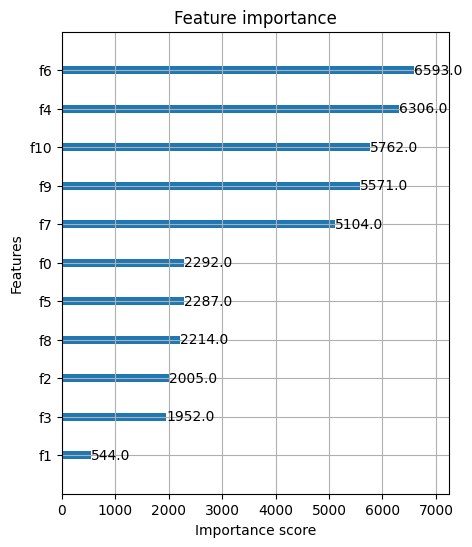

In [24]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(5, 6))
plot_importance(model, ax=ax)